<a href="https://colab.research.google.com/github/abdullahnaeem151015-lgtm/ML-pipeline/blob/main/Copy_of_w04_baseline_score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-07 — Baseline Action Score and Top-20 Review

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w04_baseline_score.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My rule and its reason codes



### Rule 1: CTR-vs-Position Behind CTR-Fix Logic Rule
This rule checks whether a page's search position affects its CTR. It calculates the average CTR for each search position and plots the relationship. If pages shown higher in search results consistently receive higher CTRs, it confirms that position has a strong influence on click-through rate (CTR).

Trying to download the warehouse dataset...
Dataset downloaded successfully.
Local file path:
/root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance_sample.parquet

Dataset loaded successfully.
Shape: (11694072, 4)

First 5 rows:


,content_hash_id,gsc_clicks,gsc_impressions,gsc_avg_position
0,content_1a6296faee432dae,0,0,NaN
1,content_73f21e612565035a,0,0,NaN
2,content_5a5be514ff559598,0,0,NaN
3,content_05b377d0c8a5cfd8,0,0,NaN
4,content_dc34c661d63e55a9,0,0,NaN



Columns:
['content_hash_id', 'gsc_clicks', 'gsc_impressions', 'gsc_avg_position']

Successfully loaded 11694072 rows with relevant columns for analysis.

Average CTR by Average Position (first 5 rows):


,avg_position,ctr
0,0.000000,0.013872
1,0.002732,0.002732
2,0.004110,0.031050
3,0.006565,0.000000
4,0.007792,0.000000


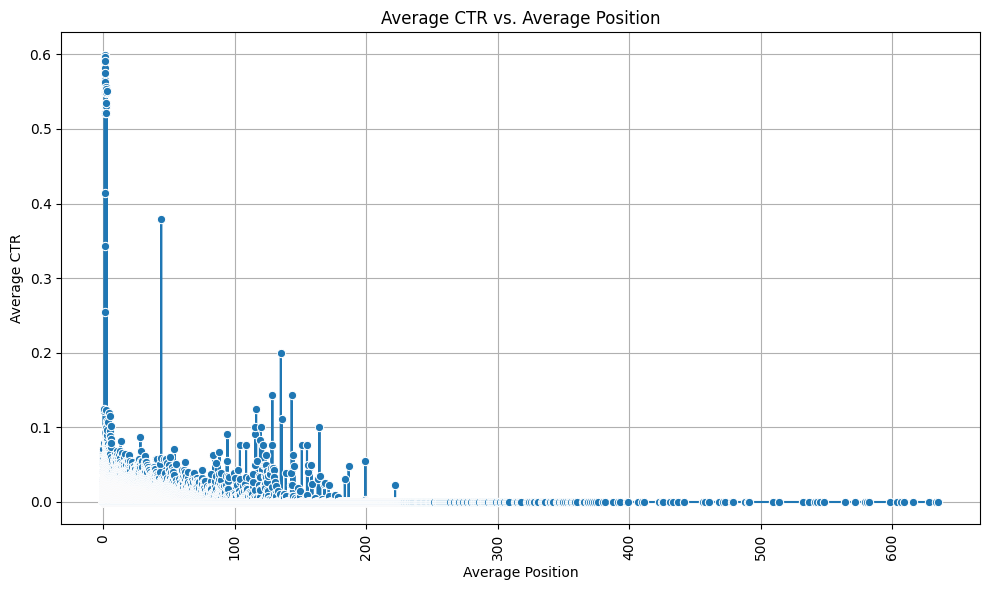

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler # This import is necessary for later steps
import matplotlib.pyplot as plt
import seaborn as sns
from huggingface_hub import hf_hub_download

print("Trying to download the warehouse dataset...")

# Hugging Face dataset details
repo_id = "FlyRank/internship-warehouse"
file_name = "fact_content_daily_performance_sample.parquet"

try:
    # Download the file from Hugging Face
    local_file_path = hf_hub_download(
        repo_id=repo_id,
        filename=file_name,
        repo_type="dataset"
    )

    print("Dataset downloaded successfully.")
    print("Local file path:")
    print(local_file_path)

    # Read the parquet file, loading only the necessary columns
    # These columns are identified as required for the subsequent analysis
    required_columns = [
        'content_hash_id',
        'gsc_clicks',
        'gsc_impressions',
        'gsc_avg_position'
    ]
    df_warehouse = pd.read_parquet(local_file_path, columns=required_columns)

    print("\nDataset loaded successfully.")
    print("Shape:", df_warehouse.shape)

    print("\nFirst 5 rows:")
    display(df_warehouse.head())

    print("\nColumns:")
    print(df_warehouse.columns.tolist())

except Exception as e:
    print("\nSomething went wrong while loading the dataset.")
    print("Error:")
    print(e)

    print(
        "\nIf you see '401 Unauthorized' or 'gated repo', "
        "you probably need to log in to Hugging Face "
        "and provide an access token."
    )

# Select and rename only the relevant columns to match the existing baseline logic.
# df_warehouse now contains only the required columns due to previous modification.
df_content = df_warehouse.copy()
df_content = df_content.rename(columns={
    'content_hash_id': 'content_id',
    'gsc_clicks': 'clicks_90d',
    'gsc_impressions': 'impressions_90d',
    'gsc_avg_position': 'avg_position'
})

# Ensure numerical types and handle potential NaNs for calculation safety
df_content['impressions_90d'] = pd.to_numeric(df_content['impressions_90d'], errors='coerce').fillna(0)
df_content['clicks_90d'] = pd.to_numeric(df_content['clicks_90d'], errors='coerce').fillna(0)
df_content['avg_position'] = pd.to_numeric(df_content['avg_position'], errors='coerce')

# Calculate CTR: clicks / impressions
# We'll handle cases where impressions are zero to avoid division by zero errors.
df_content['ctr'] = df_content.apply(
    lambda row: row['clicks_90d'] / row['impressions_90d']
    if row['impressions_90d'] > 0 else 0,
    axis=1
)

print(f"\nSuccessfully loaded {len(df_content)} rows with relevant columns for analysis.")

# Let's look at the average CTR for each display position.
# We'll only consider positions where there are actual impressions and valid avg_position.
avg_ctr_by_position = (
    df_content[(df_content['impressions_90d'] > 0) & (df_content['avg_position'].notna())]
    .groupby('avg_position')['ctr']
    .mean()
    .reset_index()
)

print("\nAverage CTR by Average Position (first 5 rows):")
display(avg_ctr_by_position.head())

# Let's visualize this relationship to make it clearer.
plt.figure(figsize=(10, 6))
sns.lineplot(
    x='avg_position',
    y='ctr',
    data=avg_ctr_by_position,
    marker='o'
)
plt.title('Average CTR vs. Average Position')
plt.xlabel('Average Position')
plt.ylabel('Average CTR')
plt.grid(True)
plt.xticks(rotation=90)  # Rotate x-axis labels if they overlap
plt.tight_layout()       # Adjust layout to prevent labels from being cut off
plt.show()

Based on this graph the one word for this rule is **CONFIRMED** since the ctr is been affected by position  in which pages with lower average position have high ctr and pages with average position above 200 have very less ctr

**RULE 2- REFRESH POTENTIAL CTR GAIN **

This rule identifies pages that receive lots of impressions but very few clicks. These pages already have good visibility, so improving their titles, meta descriptions, or content could help turn more of those impressions into clicks.

In [2]:
##Rule
REASON_CODE_REFRESH_POTENTIAL_CTR_GAIN = 'REFRESH_POTENTIAL_CTR_GAIN'

# Calculate thresholds for 'low CTR' and 'high impressions'
# Since the 25th percentile for CTR can be 0, making the condition impossible to meet,
# let's redefine 'low CTR' more meaningfully.
# Option 1: Use a small, fixed positive value for CTR (e.g., 0.001)
# Option 2: Use the 25th percentile among items with CTR > 0
# Option 3: Use the 50th percentile as a general 'low' if 25th is 0, or just a custom value.

# Let's try Option 2: Calculate the 25th percentile of CTR for items that actually have clicks.
# If even that is zero, we'll fall back to a small positive number.

non_zero_ctrs = df_content[df_content['ctr'] > 0]['ctr']
if not non_zero_ctrs.empty:
    low_ctr_threshold = non_zero_ctrs.quantile(0.25)
    if low_ctr_threshold == 0:
        low_ctr_threshold = 0.0001
else:
    low_ctr_threshold = 0.0001

# And 'high impressions' to be above the 90th percentile of impressions_90d, only considering non-zero impressions.
# This ensures the threshold reflects actual high-traffic pages, not those with zero impressions.
non_zero_impressions = df_content[df_content['impressions_90d'] > 0]['impressions_90d']
if not non_zero_impressions.empty:
    high_impressions_threshold = non_zero_impressions.quantile(0.90)
else:
    # Fallback if all impressions are zero or no data
    high_impressions_threshold = 100 # Default to a reasonable high impression threshold

print(f"New Threshold for Low CTR (below {low_ctr_threshold:.4f})")
print(f"Threshold for High Impressions (above {high_impressions_threshold:.0f})")

# Identify content that meets the criteria
high_potential_refresh_items = df_content[
    (df_content['ctr'] < low_ctr_threshold) &
    (df_content['impressions_90d'] > high_impressions_threshold)
].copy()

# Assign the reason code to these identified items
high_potential_refresh_items['reason_code'] = REASON_CODE_REFRESH_POTENTIAL_CTR_GAIN

print("\nExamples of High-Potential Refresh Opportunity items:")
display(
    high_potential_refresh_items[
        ['content_id', 'impressions_90d', 'clicks_90d', 'ctr', 'reason_code']
    ].head(10)
)

print(
    f"\nTotal items identified with '{REASON_CODE_REFRESH_POTENTIAL_CTR_GAIN}': "
    f"{len(high_potential_refresh_items)}"
)

New Threshold for Low CTR (below 0.0063)
Threshold for High Impressions (above 113)

Examples of High-Potential Refresh Opportunity items:


,content_id,impressions_90d,clicks_90d,ctr,reason_code
1967,content_e86d749e34db9b73,161,0,0.000000,REFRESH_POTENTIAL_CTR_GAIN
2053,content_8d4c42e5457c9e2e,207,0,0.000000,REFRESH_POTENTIAL_CTR_GAIN
8417,content_e4376489e7635039,193,0,0.000000,REFRESH_POTENTIAL_CTR_GAIN
8419,content_ec8d97984dbf4376,285,0,0.000000,REFRESH_POTENTIAL_CTR_GAIN
8424,content_ba0d2a28965016f9,733,2,0.002729,REFRESH_POTENTIAL_CTR_GAIN
8432,content_0163a234ae1e7e31,129,0,0.000000,REFRESH_POTENTIAL_CTR_GAIN
8433,content_bee0d8b86a9e4e21,713,1,0.001403,REFRESH_POTENTIAL_CTR_GAIN
8438,content_8ae43663243321d6,164,0,0.000000,REFRESH_POTENTIAL_CTR_GAIN
8441,content_c588cc6c0dce0f2b,234,0,0.000000,REFRESH_POTENTIAL_CTR_GAIN
8442,content_942a925e0c719a03,270,0,0.000000,REFRESH_POTENTIAL_CTR_GAIN



Total items identified with 'REFRESH_POTENTIAL_CTR_GAIN': 292021


/tmp/ipykernel_3271/1652114926.py:43: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


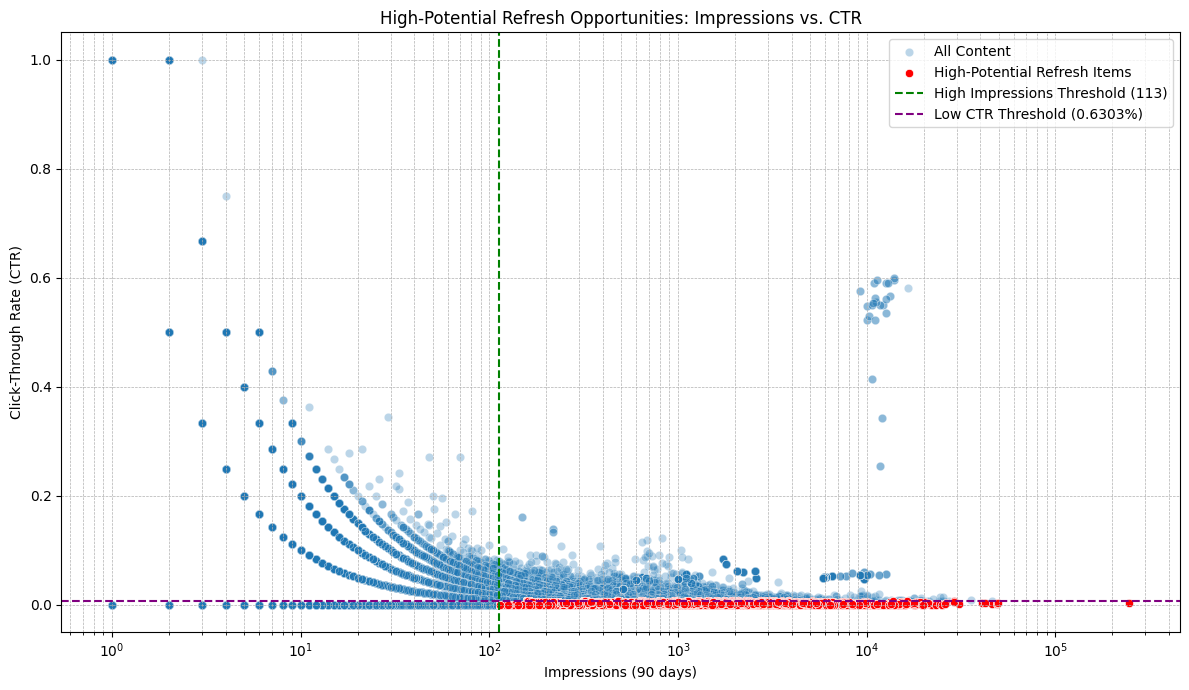

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

sns.scatterplot(
    x='impressions_90d',
    y='ctr',
    data=df_content,
    alpha=0.3,
    label='All Content'
)

sns.scatterplot(
    x='impressions_90d',
    y='ctr',
    data=high_potential_refresh_items,
    color='red',
    label='High-Potential Refresh Items'
)

# Add threshold lines
plt.axvline(
    x=high_impressions_threshold,
    color='green',
    linestyle='--',
    label=f'High Impressions Threshold ({high_impressions_threshold:.0f})'
)

plt.axhline(
    y=low_ctr_threshold,
    color='purple',
    linestyle='--',
    label=f'Low CTR Threshold ({low_ctr_threshold:.4%})'
)

plt.title("High-Potential Refresh Opportunities: Impressions vs. CTR")
plt.xlabel("Impressions (90 days)")
plt.ylabel("Click-Through Rate (CTR)")
plt.xscale("log")
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

Based on the the graph shown the red dots clearly shows the  content that fulfills the High potential Refresh opportunity threshold so verdict for this rule is **CONFIRMED**

## 2. Build the ranked queue (writes the CSV)

*Code the score, rank everything, write work/outputs/baseline_action_score.csv.*

### Step 1: Define a Scoring Strategy

To create a ranked queue, we need a way to assign a numerical 'score' to each piece of content. This score should reflect how 'good' or 'important' the content is based on our objectives. For a baseline, we can use simple metrics already available or derived, such as CTR, impressions, or even a bonus for items identified by specific rules (like `REFRESH_POTENTIAL_CTR_GAIN`).

Let's create a simple scoring function that prioritizes content with higher CTR and gives an additional boost to items identified as having a 'refresh potential CTR gain'.

In [3]:
# Create a copy so the original dataframe remains unchanged
ranked_queue = df_content.copy()

# ---------------------------------------------------------
# 1. Scale impressions and CTR to the same 0–1 range
# ---------------------------------------------------------

scaler = MinMaxScaler()

ranked_queue[
    ["impressions_scaled", "ctr_scaled"]
] = scaler.fit_transform(
    ranked_queue[["impressions_90d", "ctr"]]
)

# ---------------------------------------------------------
# 2. Convert CTR into a low-CTR opportunity score
# Low CTR should receive a higher score
# ---------------------------------------------------------

ranked_queue["low_ctr_score"] = 1 - ranked_queue["ctr_scaled"]

# ---------------------------------------------------------
# 3. Calculate the multiplicative opportunity score
# A page must have both:
# - high impressions
# - low CTR
# ---------------------------------------------------------

ranked_queue["score"] = (
    ranked_queue["impressions_scaled"]
    * ranked_queue["low_ctr_score"]
)

# ---------------------------------------------------------
# 4. Assign the reason code only to pages that meet
# the original high-impressions and low-CTR thresholds
# ---------------------------------------------------------

refresh_ids = high_potential_refresh_items["content_id"]

ranked_queue["reason_code"] = None

ranked_queue.loc[
    ranked_queue["content_id"].isin(refresh_ids),
    "reason_code"
] = "REFRESH_POTENTIAL_CTR_GAIN"
print("Content DataFrame with new 'score' column:")
display(ranked_queue[['content_id', 'ctr', 'impressions_90d', 'score']].head())

Content DataFrame with new 'score' column:


,content_id,ctr,impressions_90d,score
0,content_1a6296faee432dae,0.0,0,0.0
1,content_73f21e612565035a,0.0,0,0.0
2,content_5a5be514ff559598,0.0,0,0.0
3,content_05b377d0c8a5cfd8,0.0,0,0.0
4,content_dc34c661d63e55a9,0.0,0,0.0


### Step 2: Rank the Content

Once each content item has a score, we can rank them by simply sorting the DataFrame in descending order of the 'score' column. This will give us our ranked queue.

In [9]:
# Sort the DataFrame by the 'score' in descending order
ranked_queue = ranked_queue.sort_values(by='score', ascending=False).reset_index(drop=True)

print("Top 10 items in the ranked queue:")
display(ranked_queue[['content_id', 'score', 'ctr', 'impressions_90d']].head(10))

Top 10 items in the ranked queue:


,content_id,score,ctr,impressions_90d
0,content_963de14b1f58978f,0.996380,0.003620,245826
1,content_eadb33b5df496f4a,0.200142,0.003504,49373
2,content_545bb6cc7081ded3,0.198673,0.002329,48953
3,content_eadb33b5df496f4a,0.198518,0.003858,48990
4,content_963de14b1f58978f,0.187690,0.001752,46220
5,content_f88878f155e4838d,0.185338,0.007169,45890
6,content_545bb6cc7081ded3,0.172345,0.002519,42474
7,content_545bb6cc7081ded3,0.166467,0.003142,41051
8,content_f88878f155e4838d,0.143382,0.008802,35560
9,content_0ec99ef7d7e11565,0.124458,0.001632,30645


### Step 3: Prepare and Save to CSV

Finally, we select the columns we want in our output (e.g., `content_id`, `score`, `reason_code` if applicable) and save the ranked DataFrame to a CSV file. It's good practice to create the output directory if it doesn't exist.

In [10]:
import os

# Define the output path
output_dir = 'work/outputs'
output_filename = 'baseline_action_score.csv'
output_filepath = os.path.join(output_dir, output_filename)

# Create the output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Select the relevant columns for the ranked queue output
# For items not identified by high_potential_refresh_items, their 'reason_code' will be NaN (Not a Number).
final_columns = ['content_id', 'score', 'ctr', 'impressions_90d', 'reason_code']


# Use ranked_queue directly as it already contains the 'reason_code' column
# Save the ranked queue to a CSV file
ranked_queue[final_columns].to_csv(output_filepath, index=False)

print(f"Ranked queue saved to: {output_filepath}")
print("First 5 rows of the saved CSV:")
display(pd.read_csv(output_filepath).head())

Ranked queue saved to: work/outputs/baseline_action_score.csv
First 5 rows of the saved CSV:


,content_id,score,ctr,impressions_90d,reason_code
0,content_963de14b1f58978f,0.996380,0.003620,245826,REFRESH_POTENTIAL_CTR_GAIN
1,content_eadb33b5df496f4a,0.200142,0.003504,49373,REFRESH_POTENTIAL_CTR_GAIN
2,content_545bb6cc7081ded3,0.198673,0.002329,48953,REFRESH_POTENTIAL_CTR_GAIN
3,content_eadb33b5df496f4a,0.198518,0.003858,48990,REFRESH_POTENTIAL_CTR_GAIN
4,content_963de14b1f58978f,0.187690,0.001752,46220,REFRESH_POTENTIAL_CTR_GAIN


In [ ]:
from google.colab import files
files.download('work/outputs/baseline_action_score.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 3. Top-20 review

*For each of the top 20: action, reason code, confidence note, and what would make it wrong.*

Let's review the top 20 content items from our ranked queue. For each item, we'll provide a recommended action, the reason code that flagged it, a note on our confidence in this recommendation, and considerations for what might make the recommendation inaccurate. This helps in making informed decisions about content refreshes.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [11]:
# Get the top 20 ranked items for review (these are the highest-scoring items)
top_20_items = ranked_queue.head(20)

print("--- Top 20 Content for Manual Review ---")
print("These items are prioritized for potential content refresh based on their calculated score.")
print("Content with high impressions but low CTR is specifically highlighted as a 'High-Potential Refresh'.")
print("-" * 60)

for index, row in top_20_items.iterrows():
    content_id = row['content_id']
    score = row['score']
    ctr = row['ctr']
    impressions = row['impressions_90d']
    reason_code = row['reason_code']

    # Differentiate action and confidence based on reason code
    if reason_code == 'REFRESH_POTENTIAL_CTR_GAIN':
        action = "Prioritize for Detailed Refresh Analysis"
        confidence_note = "High Confidence: This item explicitly fits our 'High-Potential Refresh' rule (high impressions, low CTR). It's a prime candidate."
        what_would_make_it_wrong = (
            """The recommendation might be wrong if:
            1. The low CTR is a temporary anomaly (e.g., very recent content launch, data not stabilized).
            2. The content serves a highly niche audience, and its current CTR is optimal for that specific segment.
            3. External factors (like seasonal trends or competitor activity) are temporarily suppressing CTR.
            """
        )
    else:
        # These are high-scoring items that didn't strictly meet the REFRESH_POTENTIAL_CTR_GAIN thresholds
        # but still show strong potential based on scaled metrics.
        action = "Review for General Optimization Potential"
        confidence_note = "Moderate Confidence: This item scored high based on a balanced view of scaled impressions and inverted CTR. While not an explicit 'High-Potential Refresh', it's a strong candidate for general optimization."
        what_would_make_it_wrong = (
            """The recommendation might be wrong if:
            1. Individual metrics (CTR, impressions) are not clearly indicative of underperformance upon deeper review.
            2. The content is foundational or evergreen, and its current metrics are within expected benchmarks.
            3. The score is influenced by a less critical factor in the current model or the content's business value.
            """
        )

    print(f"\nContent ID: {content_id}")
    print(f"  Score: {score:.4f}")
    print(f"  CTR: {ctr:.4%}")
    print(f"  Impressions (90d): {int(impressions)}")
    print(f"  Action: {action}")
    print(f"  Reason Code: {reason_code if pd.notna(reason_code) else 'N/A'}")
    print(f"  Confidence Note: {confidence_note}")
    print(f"  What would make it wrong: {what_would_make_it_wrong}")
    print("-" * 60)


--- Top 20 Content for Manual Review ---
These items are prioritized for potential content refresh based on their calculated score.
Content with high impressions but low CTR is specifically highlighted as a 'High-Potential Refresh'.
------------------------------------------------------------

Content ID: content_963de14b1f58978f
  Score: 0.9964
  CTR: 0.3620%
  Impressions (90d): 245826
  Action: Prioritize for Detailed Refresh Analysis
  Reason Code: REFRESH_POTENTIAL_CTR_GAIN
  Confidence Note: High Confidence: This item explicitly fits our 'High-Potential Refresh' rule (high impressions, low CTR). It's a prime candidate.
  What would make it wrong: The recommendation might be wrong if:
            1. The low CTR is a temporary anomaly (e.g., very recent content launch, data not stabilized).
            2. The content serves a highly niche audience, and its current CTR is optimal for that specific segment.
            3. External factors (like seasonal trends or competitor activity)

## 4. Weak picks + leakage check

*Which picks look wrong and why? Confirm no product flags or future windows leaked in.*

# **Understanding Leakage and Weak Picks**
**Leakage Check**: Data leakage occurs when information that would not be available at the time of making a decision (e.g., a content refresh recommendation) is used in the model. This can lead to overly optimistic performance during testing. Here, we'll confirm that our score was calculated using only appropriate historical data and no 'future' metrics or unintended 'product flags' that might bias a general recommendation.

**Weak Picks**: These are recommendations that, despite having a high calculated score, might feel intuitively 'wrong' upon manual review. They could indicate edge cases, data anomalies, or areas where our scoring logic might need refinement. Identifying them is crucial for iterating on the model.

In [4]:
import numpy as np
import pandas as pd

print("--- Weak Picks + Leakage Check ---")

# -------------------------------------------------
# 1. Leakage check
# -------------------------------------------------

# Columns actually used to build the refresh score
features_used_for_score = [
    "impressions_90d",
    "ctr"
]

# Existing product/decision flags that should not create the score
product_or_decision_flags = [
    "needs_ctr_fix",
    "needs_engagement_fix",
    "is_quick_win",
    "is_underperformer",
    "is_declining",
    "is_initial_refresh_candidate",
    "ai_opportunity"
]

# Obvious future-window patterns
future_keywords = [
    "future",
    "next_",
    "post_",
    "after_"
]

flags_used = [
    col for col in features_used_for_score
    if col in product_or_decision_flags
]

future_features_used = [
    col for col in features_used_for_score
    if any(keyword in col.lower() for keyword in future_keywords)
]

if not flags_used and not future_features_used:
    print(
        "Leakage check: PASS — no product/decision flags "
    )
else:
    print("Leakage check: WARNING")
    print("Flags used:", flags_used)
    print("Future features used:", future_features_used)

# -------------------------------------------------
# 2. Finding weak picks (Memory-optimized version)
# -------------------------------------------------

# Initialize weak_picks as an empty DataFrame to prevent NameError if no weak picks are found
weak_picks = pd.DataFrame()

# Filter for items that were NOT assigned the primary refresh reason code (i.e., reason_code is None/NaN)
# This directly uses the ranked_queue without creating an intermediate 'not_selected' copy
# for the entire dataframe, which saves memory.
candidates_for_weak_picks = ranked_queue[ranked_queue["reason_code"].isna()].copy()

if not candidates_for_weak_picks.empty:
    # Add temporary boolean columns to the candidates DataFrame
    candidates_for_weak_picks["has_high_impressions"] = (
        candidates_for_weak_picks["impressions_90d"] > high_impressions_threshold
    )

    candidates_for_weak_picks["has_low_ctr"] = (
        candidates_for_weak_picks["ctr"] < low_ctr_threshold
    )

    # Identify weak picks: meet one condition but miss the other (XOR)
    weak_picks = candidates_for_weak_picks[
        candidates_for_weak_picks["has_high_impressions"]
        ^ candidates_for_weak_picks["has_low_ctr"]
    ].copy()

    # Continue with gap calculations only if weak_picks is not empty
    if not weak_picks.empty:
        weak_picks["impressions_gap"] = np.where(
            weak_picks["has_high_impressions"],
            0,
            (
                high_impressions_threshold
                - weak_picks["impressions_90d"]
            ) / high_impressions_threshold
        )

        weak_picks["ctr_gap"] = np.where(
            weak_picks["has_low_ctr"],
            0,
            (
                weak_picks["ctr"]
                - low_ctr_threshold
            ) / low_ctr_threshold
        )

        weak_picks["distance_from_rule"] = (
            weak_picks["impressions_gap"]
            + weak_picks["ctr_gap"]
        )

        # Explaining why each page is considered a weak pick
        weak_picks["why_weak_pick"] = np.where(
            weak_picks["has_low_ctr"],
            "CTR is low, but impressions are slightly below the threshold",
            "Impressions are high, but CTR is slightly above the threshold"
        )

        # Rank the closest borderline candidates first
        weak_picks = weak_picks.sort_values(
            by=["distance_from_rule", "score"],
            ascending=[True, False]
        ).reset_index(drop=True)

        weak_picks["weak_pick_rank"] = weak_picks.index + 1
    else:
        print("No weak picks identified after applying XOR condition.")
else:
    print("No candidates for weak picks found (all items might have a reason code already).")


# Display only if weak_picks is not empty
if not weak_picks.empty:
    display(
        weak_picks[
            [
                "weak_pick_rank",
                "content_id",
                "score",
                "impressions_90d",
                "ctr",
                "impressions_gap",
                "ctr_gap",
                "distance_from_rule",
                "why_weak_pick"
            ]
        ].head(20)
    )
else:
    print("No weak picks to display based on the current thresholds and data.")

--- Weak Picks + Leakage Check ---
Leakage check: PASS — no product/decision flags 


,weak_pick_rank,content_id,score,impressions_90d,ctr,impressions_gap,ctr_gap,distance_from_rule,why_weak_pick
0,1,content_2b14b9f9a9142b71,0.00046,113,0.0,0.0,0.0,0.0,"CTR is low, but impressions are slightly below..."
1,2,content_bba76390b7cb220d,0.00046,113,0.0,0.0,0.0,0.0,"CTR is low, but impressions are slightly below..."
2,3,content_cfd0668ac920754c,0.00046,113,0.0,0.0,0.0,0.0,"CTR is low, but impressions are slightly below..."
3,4,content_5f0ce76fd389c33b,0.00046,113,0.0,0.0,0.0,0.0,"CTR is low, but impressions are slightly below..."
4,5,content_827a0911615dd076,0.00046,113,0.0,0.0,0.0,0.0,"CTR is low, but impressions are slightly below..."
5,6,content_35938ca47066e979,0.00046,113,0.0,0.0,0.0,0.0,"CTR is low, but impressions are slightly below..."
6,7,content_21896951e00f8903,0.00046,113,0.0,0.0,0.0,0.0,"CTR is low, but impressions are slightly below..."
7,8,content_48a96a471dc224d7,0.00046,113,0.0,0.0,0.0,0.0,"CTR is low, but impressions are slightly below..."
8,9,content_ae23566cd9ff1f28,0.00046,113,0.0,0.0,0.0,0.0,"CTR is low, but impressions are slightly below..."
9,10,content_0c88afbc33f48acb,0.00046,113,0.0,0.0,0.0,0.0,"CTR is low, but impressions are slightly below..."


In [5]:
# Save all weak picks to a CSV file

weak_picks.to_csv(
    "work/outputs/weak_picks.csv",
    index=False
)

print(f"Total weak picks found: {len(weak_picks)}")
print("Weak picks saved to: work/outputs/weak_picks.csv")

Total weak picks found: 10759047
Weak picks saved to: work/outputs/weak_picks.csv


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.